In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
# Loading the dataset
df = pd.read_csv("pokemon.csv")

### Descriptive Statistics

In [8]:
df.head()

,id,name,generation,type_1,type_2,ability_1,ability_2,hidden_ability,is_legendary,hp,atk,def,sp_atk,sp_def,speed,total
0,1,bulbasaur,1,grass,poison,overgrow,NaN,chlorophyll,0,45,49,49,65,65,45,318
1,2,ivysaur,1,grass,poison,overgrow,NaN,chlorophyll,0,60,62,63,80,80,60,405
2,3,venusaur,1,grass,poison,overgrow,NaN,chlorophyll,0,80,82,83,100,100,80,525
3,4,charmander,1,fire,NaN,blaze,NaN,solar-power,0,39,52,43,60,50,65,309
4,5,charmeleon,1,fire,NaN,blaze,NaN,solar-power,0,58,64,58,80,65,80,405


In [9]:
df.tail()

,id,name,generation,type_1,type_2,ability_1,ability_2,hidden_ability,is_legendary,hp,atk,def,sp_atk,sp_def,speed,total
1019,1020,gouging-fire,9,fire,dragon,protosynthesis,NaN,NaN,0,105,115,121,65,93,91,590
1020,1021,raging-bolt,9,electric,dragon,protosynthesis,NaN,NaN,0,125,73,91,137,89,75,590
1021,1022,iron-boulder,9,rock,psychic,quark-drive,NaN,NaN,0,90,120,80,68,108,124,590
1022,1023,iron-crown,9,steel,psychic,quark-drive,NaN,NaN,0,90,72,100,122,108,98,590
1023,1024,terapagos,9,normal,NaN,tera-shift,NaN,NaN,1,90,65,85,65,85,60,450


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1024 entries, 0 to 1023
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              1024 non-null   int64 
 1   name            1024 non-null   object
 2   generation      1024 non-null   int64 
 3   type_1          1024 non-null   object
 4   type_2          525 non-null    object
 5   ability_1       1024 non-null   object
 6   ability_2       530 non-null    object
 7   hidden_ability  860 non-null    object
 8   is_legendary    1024 non-null   int64 
 9   hp              1024 non-null   int64 
 10  atk             1024 non-null   int64 
 11  def             1024 non-null   int64 
 12  sp_atk          1024 non-null   int64 
 13  sp_def          1024 non-null   int64 
 14  speed           1024 non-null   int64 
 15  total           1024 non-null   int64 
dtypes: int64(10), object(6)
memory usage: 128.1+ KB


In [11]:
df.describe()

,id,generation,is_legendary,hp,atk,def,sp_atk,sp_def,speed,total
count,1024.00000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000,1024.000000
mean,512.50000,4.737305,0.089844,70.166992,77.511719,72.421875,70.063477,70.188477,67.166016,427.518555
std,295.74764,2.631551,0.286098,26.638238,29.795291,29.173190,29.667576,26.646534,28.723881,112.697016
min,1.00000,1.000000,0.000000,1.000000,5.000000,5.000000,10.000000,20.000000,5.000000,175.000000
25%,256.75000,3.000000,0.000000,50.000000,55.000000,50.000000,47.000000,50.000000,45.000000,324.500000
50%,512.50000,5.000000,0.000000,68.000000,75.000000,70.000000,65.000000,66.500000,65.000000,450.000000
75%,768.25000,7.000000,0.000000,85.000000,100.000000,90.000000,90.000000,85.250000,88.250000,508.000000
max,1024.00000,9.000000,1.000000,255.000000,181.000000,230.000000,173.000000,230.000000,200.000000,720.000000


In [12]:
df.nunique()

id                1024
name              1024
generation           9
type_1              18
type_2              18
ability_1          223
ability_2          131
hidden_ability     164
is_legendary         2
hp                 107
atk                117
def                108
sp_atk             113
sp_def             103
speed              119
total              207
dtype: int64

In [49]:
# Number of missing values
df.isnull().sum()

id                  0
name                0
generation          0
type_1              0
type_2            499
ability_1           0
ability_2         494
hidden_ability    164
is_legendary        0
hp                  0
atk                 0
def                 0
sp_atk              0
sp_def              0
speed               0
total               0
dtype: int64

In [ ]:
# Filling missing values in each of the 3 columns

# For Ability 2, you can replace it with Ability 1
df['ability_2'].fillna(df['ability_1'], inplace=True)

# If Hidden Ability is missing, then it must not exist. Same with type_2
df['hidden_ability'].fillna("None", inplace=True)
df['type_2'].fillna("None", inplace=True)

In [14]:
df.columns

Index(['id', 'name', 'generation', 'type_1', 'type_2', 'ability_1',
       'ability_2', 'hidden_ability', 'is_legendary', 'hp', 'atk', 'def',
       'sp_atk', 'sp_def', 'speed', 'total'],
      dtype='object')

In [ ]:
# Renaming all columns appropriately
col_names = {
    'id': 'ID', 'name': "Name", 'generation': 'Gen', 'type_1': "Primary_Type", 'type_2': "Secondary_Type", 
    'ability_1': "Ability_1", 'ability_2': "Ability_2", 'hidden_ability': "Hidden_Ability",
    'is_legendary': "legendary", 'hp': "HP", 'atk': "Attack", 'def': "Defense", 'sp_atk': "Sp_Attack",
    'sp_def': "Sp_Defense", 'speed': "Speed", 'total': "Total"
}

df.rename(index=df['id'], columns=col_names, inplace=True)

# And drop the "ID" column
df.drop("ID", axis=1, inplace=True)

# Printing the head for confirmation
df.head()

## What is the distribution of range of all the base stats?

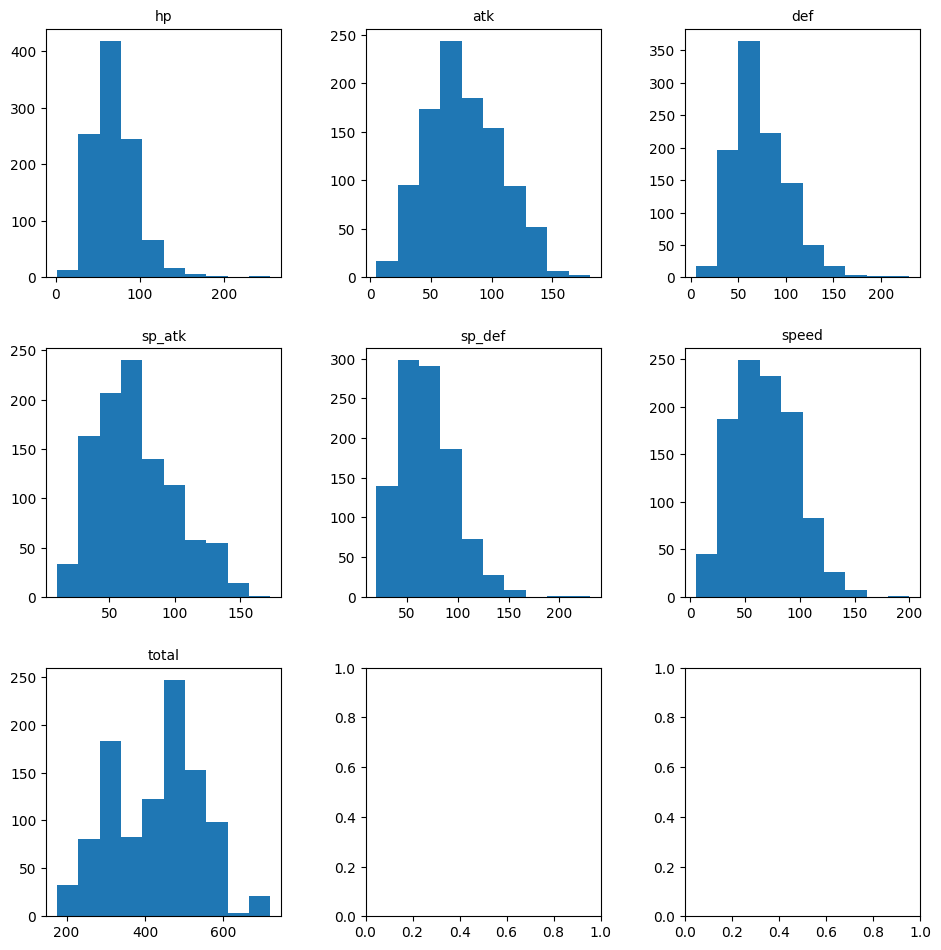

In [43]:
fig, ax = plt.subplots(3, 3, figsize=(10,10))
fig.tight_layout(pad=3)

hist_plot_cols = ['hp', 'atk', 'def', 'sp_atk', 'sp_def', 'speed', 'total']

for i in range(len(hist_plot_cols)):
    ax[i//3, i%3].hist(df[hist_plot_cols[i]])
    ax[i//3, i%3].set_title(hist_plot_cols[i], fontsize=10)

## How does Speed fare against other stats

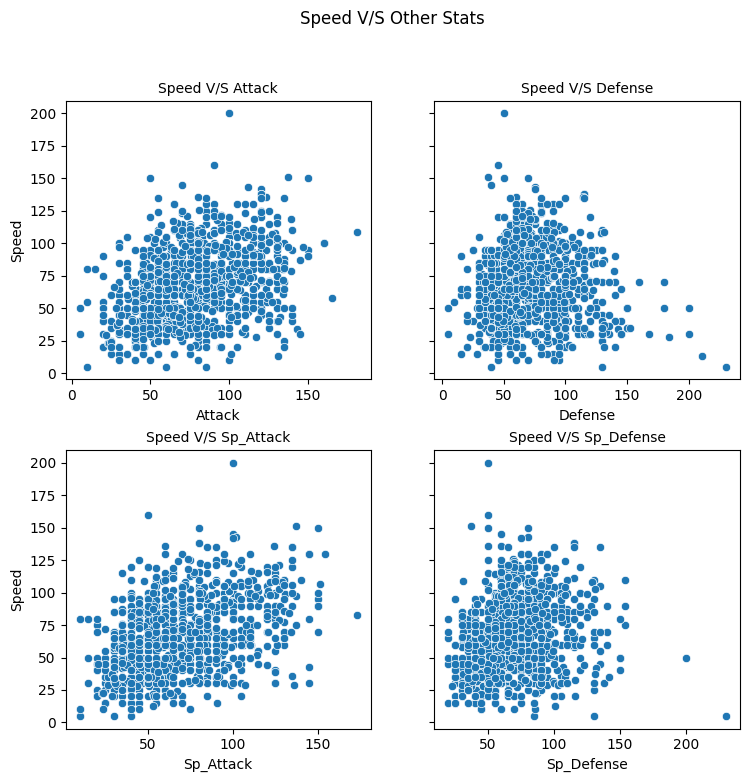

In [75]:
fig, ax = plt.subplots(2, 2, figsize=(8,8), sharey=True)

fig.suptitle("Speed V/S Other Stats")
fig.tight_layout(pad=3.0)

other_stats = ['Attack', "Defense", "Sp_Attack", "Sp_Defense"]
for i in range(len(other_stats)):
    stat = other_stats[i]
    
    sns.scatterplot(x= df[stat], y = df['Speed'], ax=ax[i//2, i%2])
    ax[i//2, i%2].set_title(f"Speed V/S {stat}", fontsize=10)

### Drawing a Correlation Map

Text(0.5, 1.0, 'Correlation of all iterable columns')

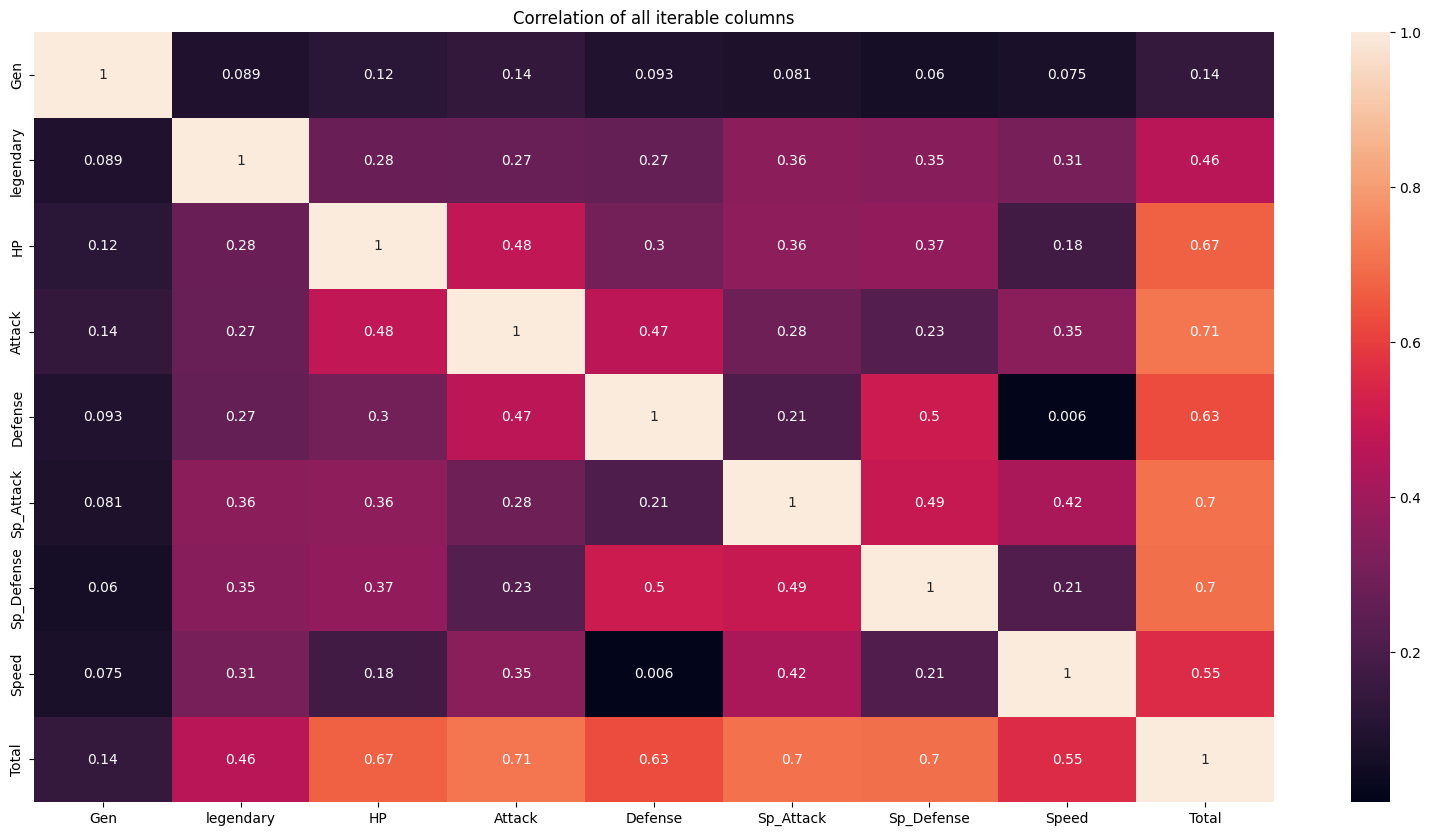

In [86]:
fig, ax = plt.subplots(figsize=(20, 10))
iterable_cols = [col for col in df.columns if df[col].dtype == np.int64]

sns.heatmap(df[iterable_cols].corr(), annot=True).set_title("Correlation of all iterable columns")